In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch

import data


In [2]:
# We can now load the datasets, combine and shuffle them to have a (close to) homogenous distribution of all sub-structures.
BATCH_SIZE = 5 # Feel free to increase this number; all the training was done on my personal machine, hence, this limitation

dataset_no_sub = data.LensingDataset('train/',['no_sub'],5000)
# train_dataset_no_sub, val_dataset_no_sub = torch.utils.data.random_split(dataset_no_sub, [0.8, 0.2])

dataset_axion = data.LensingDataset('train/',['axion'],5000)
# train_dataset_axion, val_dataset_axion = torch.utils.data.random_split(dataset_axion, [0.8, 0.2])

dataset_cdm = data.LensingDataset('train/',['cdm'],5000)
# train_dataset_cdm, val_dataset_cdm = torch.utils.data.random_split(dataset_cdm, [0.8, 0.2])

train_dataset = torch.utils.data.ConcatDataset([dataset_no_sub, dataset_axion, dataset_cdm])
# val_dataset = torch.utils.data.ConcatDataset([val_dataset_no_sub, val_dataset_axion, val_dataset_cdm])

# train_dataset, train_rest = torch.utils.data.random_split(train_dataset, [0.34, 0.66])
# val_dataset, val_rest = torch.utils.data.random_split(val_dataset, [0.34, 0.66])

# train_dataloader = torch.utils.data.DataLoader(train_dataset,shuffle=True,batch_size=BATCH_SIZE,num_workers=15)
# val_dataloader = torch.utils.data.DataLoader(val_dataset,shuffle=True,batch_size=BATCH_SIZE,num_workers=15)

# This configuration will load 5000 (low-resolution) images in total, with a 80:20 validation split. 

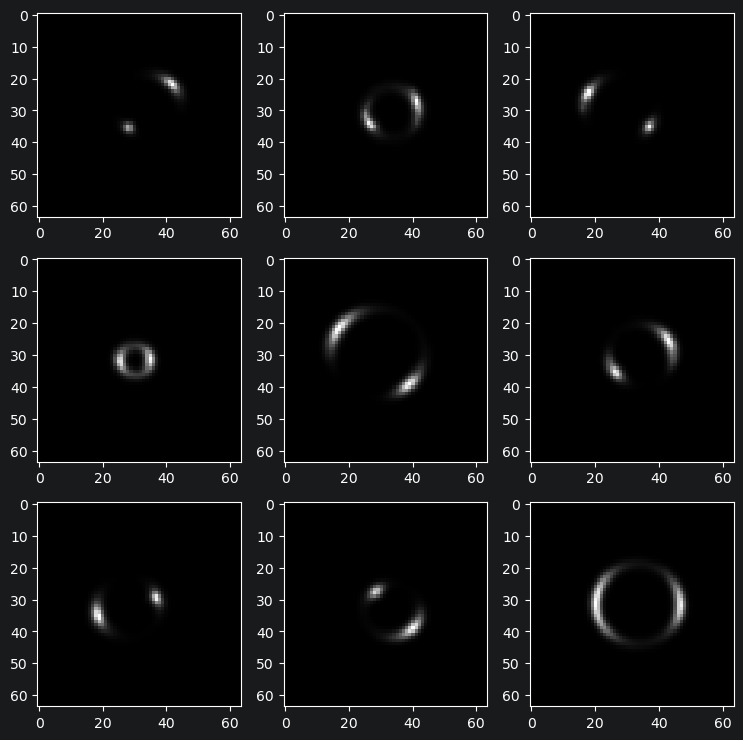

In [10]:
plot, axes = plt.subplots(3, 3)
plot.set_size_inches(9,9)
for i in range(3):
    for j in range(3):
        # axes[i][j].imshow(train_dataset[i+5000*j][0,0], cmap='grey') # This will show the first 3 images of each sub-structure class. The first row corresponds to the "no_sub" class, the second row to the "axion" class and the third row to the "cdm" class. BUT NOT CORRECT AS [0,0] REMOVES THE CHANNEL DIMENSION AND ONE SPATIAL DIMENSION, LEADING TO A 1D ARRAY INSTEAD OF A 2D IMAGE. TO FIX THIS, WE SHOULD USE [0] INSTEAD OF [0,0] TO RETAIN THE SPATIAL DIMENSIONS.

        #axes[i][j].imshow(train_dataset[i+5000*j][0], cmap='grey')
        # OR
        axes[i][j].imshow(train_dataset[i + 5000 * j].squeeze(0), cmap='grey')

        ## WHY DOES THIS [0] WORK?
        # IF TENSOR SHAPE IS (1,64,64),
        # tensor[0] -> (64,64) --> CORRECT, THIS IS THE IMAGE WE WANT TO PLOT
        # tensor[0,0] -> (64,)
        # tensor[0,0,0] -> scalar
